<a href="https://colab.research.google.com/github/FuscaLuocaG/LUNG-CANCER-ANALYSIS/blob/main/1_data_loading_first_look_%26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import gdown as gd
import seaborn as sns

import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Ingestion & Initial Profiling (First Look)



##1 - Data Loading & Immutability Check

In [4]:
# Importing dataset

file_id = '1VeLQmvR1vzq2U3z5RIOldcP45Cw_5hSa'
url = f"https://drive.google.com/uc?id={file_id}"

nameframe = "Lung Cancer.csv"

gd.download(url, nameframe, quiet= False)

df_raw = pd.read_csv('Lung Cancer.csv')


Downloading...
From: https://drive.google.com/uc?id=1VeLQmvR1vzq2U3z5RIOldcP45Cw_5hSa
To: /content/Lung Cancer.csv
100%|██████████| 93.4M/93.4M [00:01<00:00, 67.2MB/s]


## 2 - Data Completeness & Types Audit

In [5]:
pd.set_option('display.max_rows', 100)

df_raw.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [6]:
df_raw.tail()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
889995,889996,40.0,Male,Malta,2022-07-01,Stage IV,No,Passive Smoker,44.8,243,1,1,1,0,Radiation,2023-02-23,0
889996,889997,62.0,Female,Cyprus,2015-09-27,Stage II,Yes,Former Smoker,21.6,240,0,0,0,0,Surgery,2017-06-19,0
889997,889998,48.0,Female,Estonia,2016-03-27,Stage III,Yes,Never Smoked,38.6,242,1,0,0,0,Combined,2017-01-23,1
889998,889999,67.0,Female,Slovakia,2015-12-22,Stage IV,Yes,Former Smoker,18.6,194,1,1,0,0,Chemotherapy,2017-12-12,0
889999,890000,55.0,Female,Malta,2021-07-26,Stage II,Yes,Current Smoker,42.8,250,0,0,0,0,Combined,2022-10-19,0


In [29]:
df_raw['country'].unique()

array(['Sweden', 'Netherlands', 'Hungary', 'Belgium', 'Luxembourg',
       'Italy', 'Croatia', 'Denmark', 'Malta', 'Germany', 'Poland',
       'Ireland', 'Romania', 'Spain', 'Greece', 'Estonia', 'Cyprus',
       'France', 'Slovenia', 'Latvia', 'Portugal', 'Austria',
       'Czech Republic', 'Finland', 'Lithuania', 'Slovakia', 'Bulgaria'],
      dtype=object)

In [8]:
df_raw['treatment_type'].unique()

array(['Chemotherapy', 'Surgery', 'Combined', 'Radiation'], dtype=object)

In [9]:
df_raw['cancer_stage'].unique()

array(['Stage I', 'Stage III', 'Stage IV', 'Stage II'], dtype=object)

In [10]:
df_raw['smoking_status'].unique()

array(['Passive Smoker', 'Former Smoker', 'Never Smoked',
       'Current Smoker'], dtype=object)

In [11]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  890000 non-null  int64  
 1   age                 890000 non-null  float64
 2   gender              890000 non-null  object 
 3   country             890000 non-null  object 
 4   diagnosis_date      890000 non-null  object 
 5   cancer_stage        890000 non-null  object 
 6   family_history      890000 non-null  object 
 7   smoking_status      890000 non-null  object 
 8   bmi                 890000 non-null  float64
 9   cholesterol_level   890000 non-null  int64  
 10  hypertension        890000 non-null  int64  
 11  asthma              890000 non-null  int64  
 12  cirrhosis           890000 non-null  int64  
 13  other_cancer        890000 non-null  int64  
 14  treatment_type      890000 non-null  object 
 15  end_treatment_date  890000 non-nul

In [12]:
df_raw.isnull().sum()

,0
id,0
age,0
gender,0
country,0
diagnosis_date,0
cancer_stage,0
family_history,0
smoking_status,0
bmi,0
cholesterol_level,0


In [13]:
df_raw.duplicated().sum()

np.int64(0)

## 3 - Stratetic Feature Selection (Dropping Irrelevant Columns)

In [17]:
#Dropping ''id'' and ''country'' irrelevant columns for the EDA

df = df_raw.copy()

df.pop('id')
df.pop('country')

df.to_csv('/content/drive/MyDrive/Colab Notebooks/df.csv', index = False)

 Feature Selection & Data Immutability

- **Data Immutability Standard:** `df_raw` is stored intact in memory to prevent redundant disk I/O reloads during pipeline execution.
- **Noise Removal (`id`):** Dropped primary identifier to eliminate false sequential bias in tree-based algorithms.
- **Cardinality Control (`country`):** Dropped high-cardinality nominal attribute prior to encoding. This prevents matrix explosion (*Curse of Dimensionality*) across 890,000 rows and eliminates non-clinical demographic noise.

Dataset Overview & Initial Profiling

- **Dataset Scale:** 890,000 records (High-volume dataset).
- **Data Completeness:** 0 missing values across all columns (`df.isnull().sum() == 0`).
- **Feature Diversity:** Mixed data types including categorical attributes and numerical metrics.

-**Next Steps:** Load the set for the EDA.

#Exploratory Data Analysis (EDA on Training Data)





## Distribution & Synthetic Data Correlation Audit



In [30]:
# Loading the EDA dataset, and seting up a 20k size sample for speed

df_eda = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/df_eda.csv')
df_eda = df_eda.sample(n = 2000, random_state = 42)


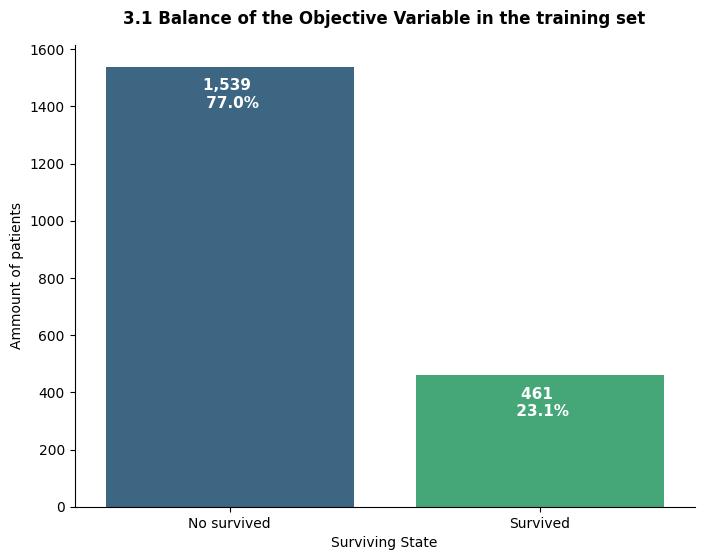

In [24]:

df_eda['survived_label'] = df_eda['survived'].map({0: 'No survived', 1: 'Survived'})

plt.figure(figsize = (8, 6))
ax = sns.countplot(data = df_eda, x = 'survived_label',hue = 'survived_label', palette = 'viridis', legend = False)

total_patients = len(df_eda)

for p in ax.patches:

  counting = int(p.get_height())

  porcentage = (counting / total_patients) * 100

  text = f'{counting:,} \n {porcentage:.1f}%'

  ax.annotate(text, (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center',
  va = 'center', xytext = (0, -20), textcoords = 'offset points', color = "white",
  fontweight = 'bold', fontsize = 11)

plt.title('3.1 Balance of the Objective Variable in the training set', pad = 15, fontweight = 'bold' )
plt.xlabel('Surviving State')
plt.ylabel('Ammount of patients')
sns.despine()

plt.show()


## Bivariate Feature Interactions

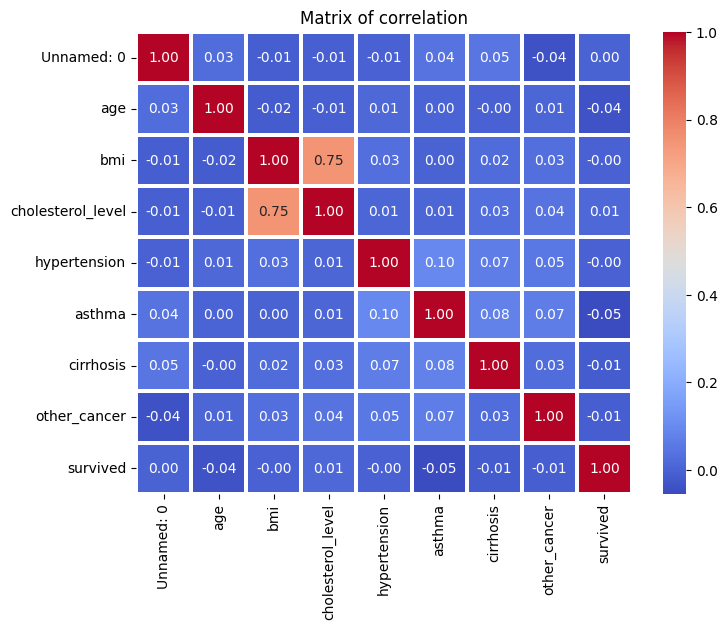

In [25]:
# Matrix of correlation

df_eda = df_eda.select_dtypes(include= 'number')

correlation_matrix = df_eda.corr(method = 'spearman', numeric_only= True)
plt.figure(figsize = (8, 6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 1.5)
plt.title('Matrix of correlation')
plt.show()



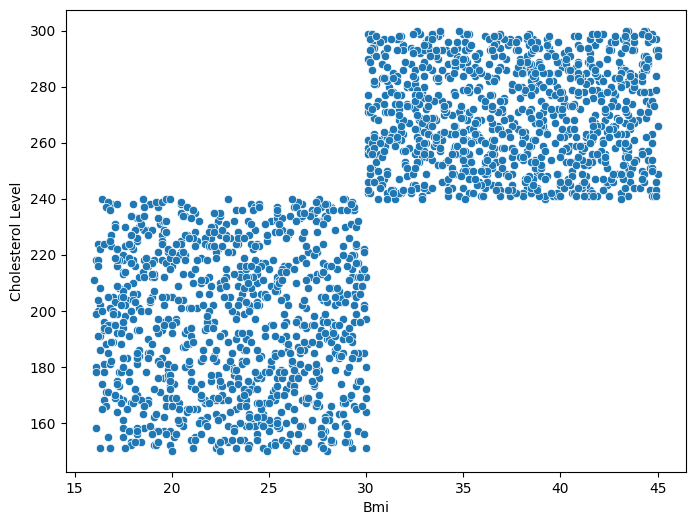

In [26]:
# Correlation between Body Mass Index and Cholesterol Level

plt.figure(figsize= (8, 6))
sns.scatterplot(x = df_eda['bmi'], y = df_eda['cholesterol_level'])
plt.ylabel('Cholesterol Level')
plt.xlabel('Bmi')
plt.show()

Exploratory Data Analysis (EDA) & Synthetic Data Discovery
- **Target Distribution:** Analyzed the `survived` class balance using percentage-annotated visualizations, verifying the class proportions in `df_eda`.
- **Correlation Matrix & Bivariate Analysis:** Computed a Spearman correlation heatmap on a strategic 20k sample to evaluate monotonic relationships among numerical features.
- **Key Discovery (Synthetic Artifacts):** Scatter plots between variables (such as BMI and Cholesterol) revealed uniform rectangular clusters rather than organic clinical distributions, and feature-target correlations hovered near $0.00$.
- **Strategic Pivot:** Concluded that the dataset is artificially generated, shifting the project's focus toward **MLOps, pipeline optimization, and large-scale model benchmarking** rather than clinical inference.

No more EDA process needed, no outliers, no null-values or specific patterns found.